### Correlation Heatmap

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../dataset/sub-data-notes-filtered-selected-columns.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_12020\2591106915.py:1: DtypeWarning: Columns (0: YEAR, 1: NOCHK, 2: BNKRUPLAST5, 3: FORECLLAST5, 4: HHSEX, 5: EDUC, 6: LIFECL, 7: EXPENSHILO) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dataset/sub-data-notes-filtered-selected-columns.csv")


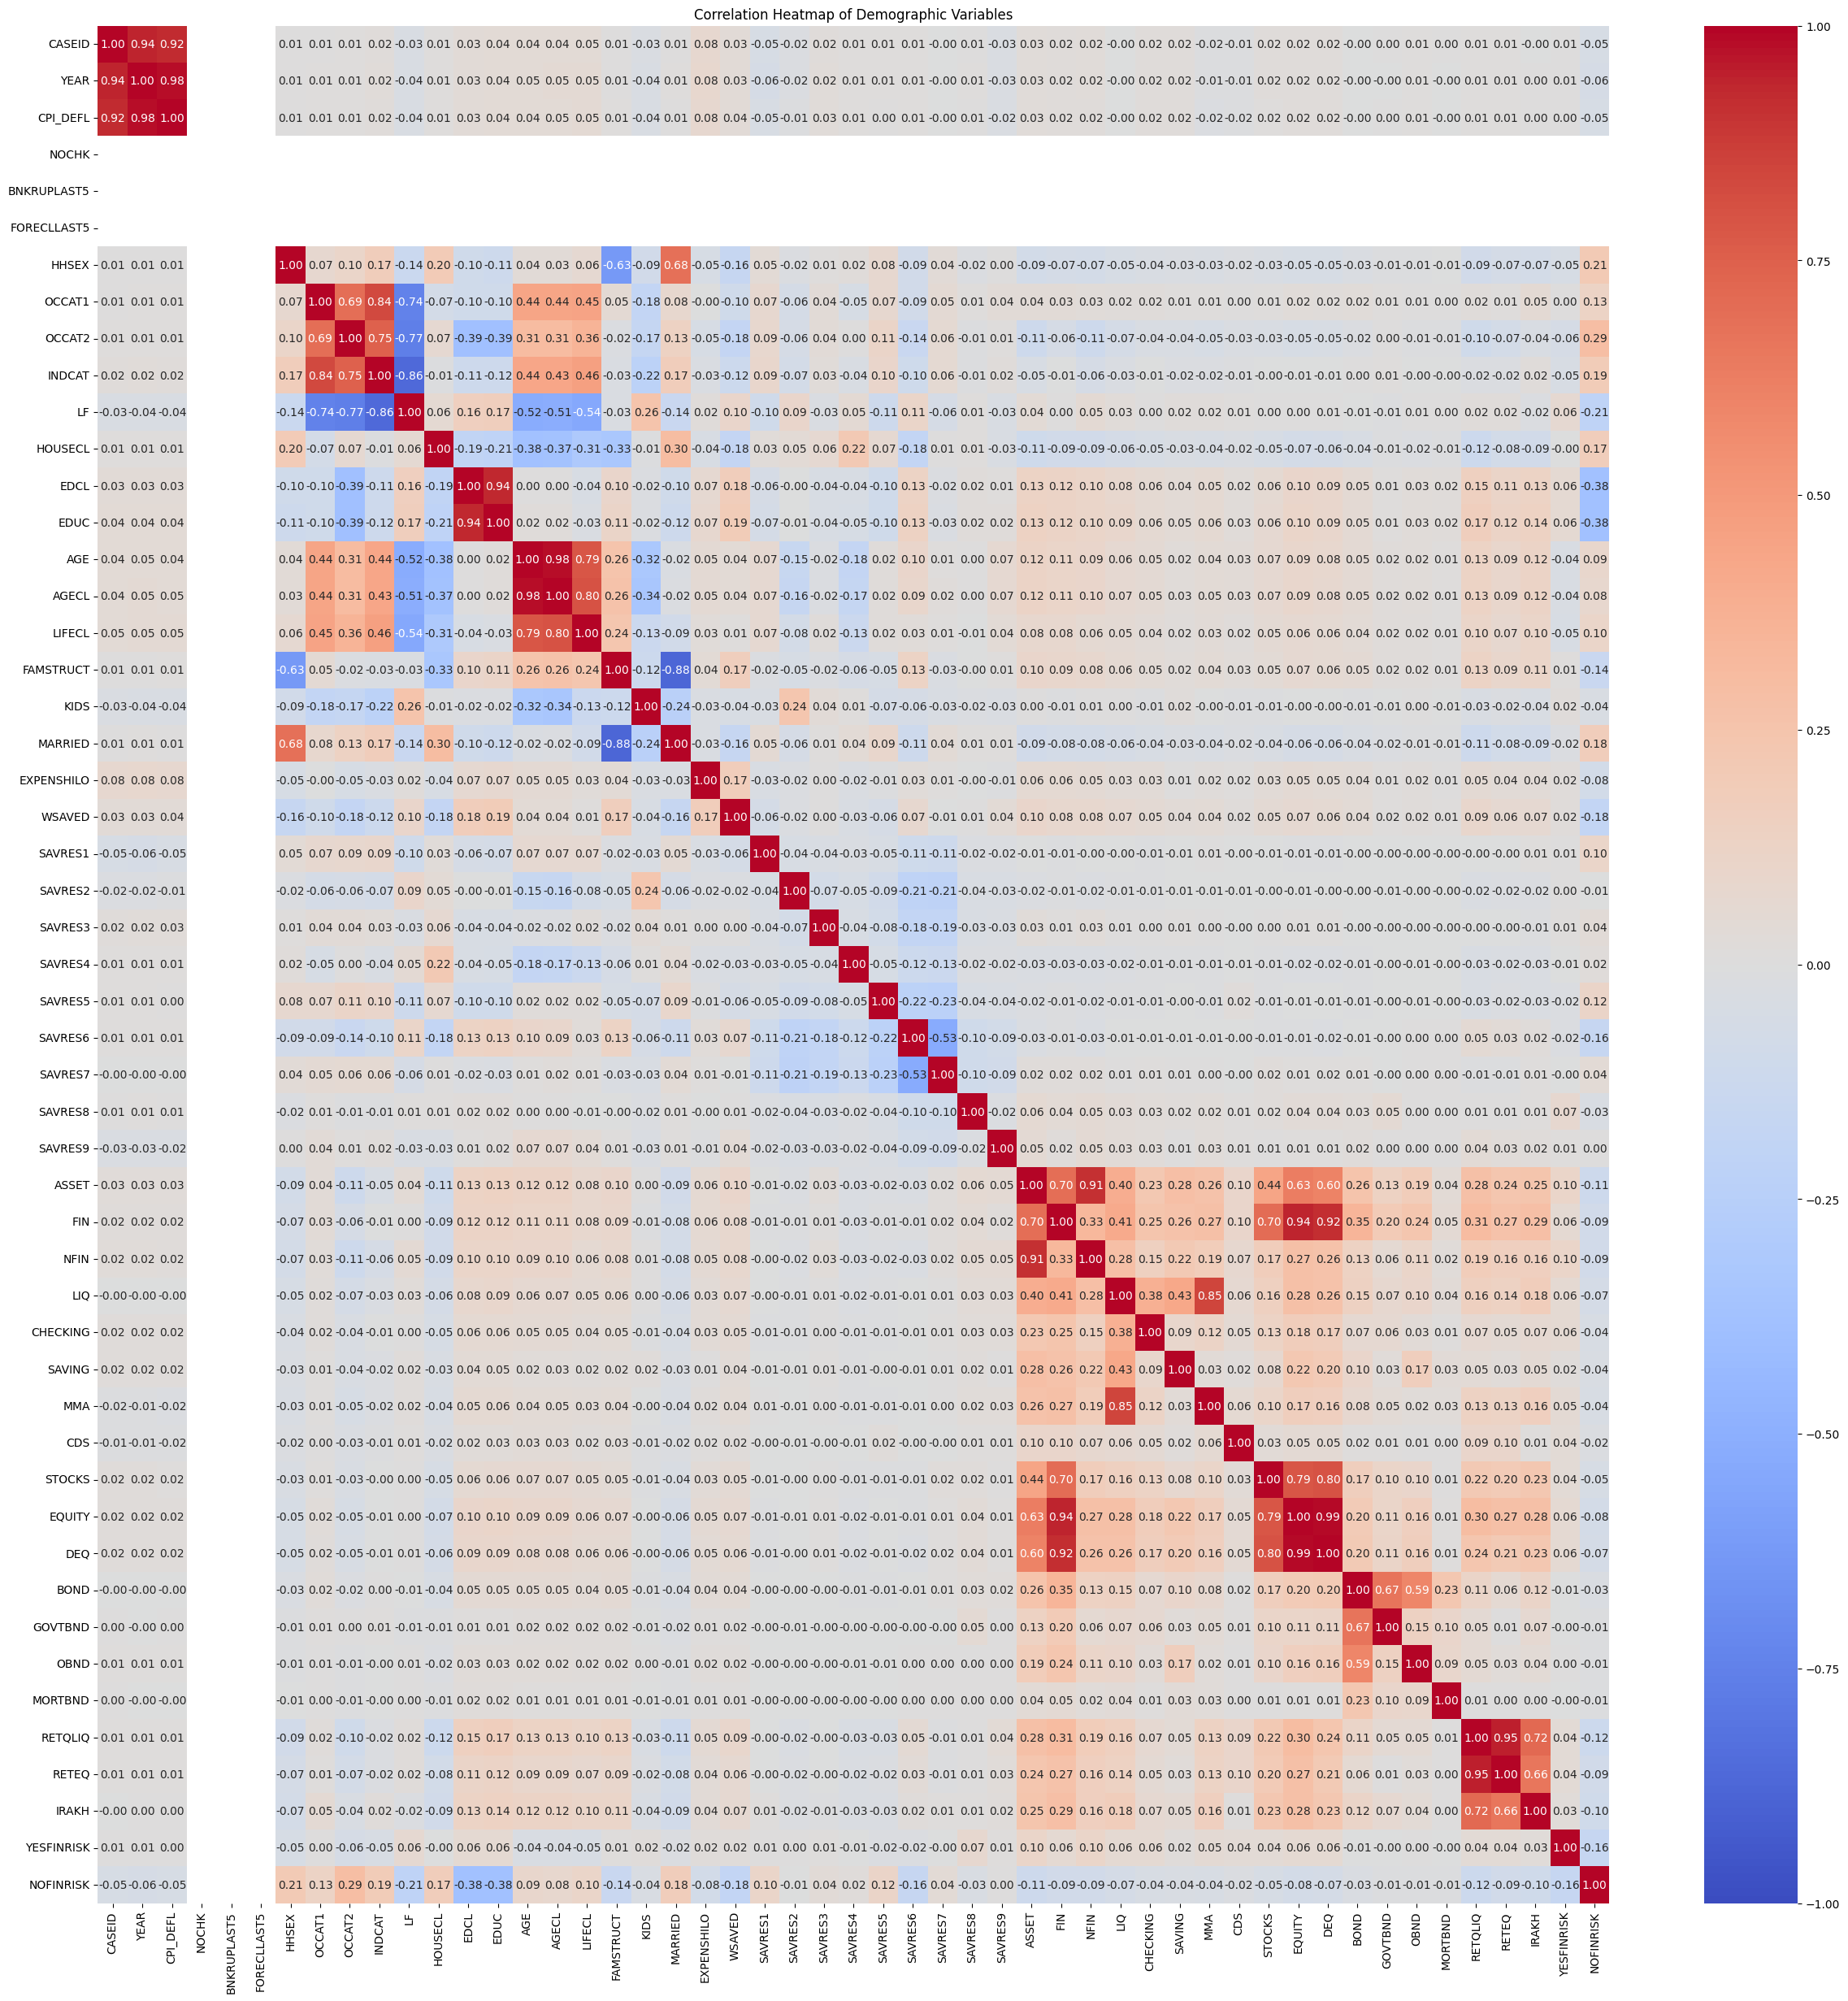

In [11]:
# 0. 데이터 숫자로 강제 변환: 공백 문자를 NaN으로 처리
df = df.apply(pd.to_numeric, errors='coerce')

# 1. 확인할 변수들만 선택
# cols_to_check = ['FAMSTRUCT', 'LIFECL']
# df = df[cols_to_check]
df_subset = df.iloc[2:]

# 2. 상관계수 행렬 계산
corr_matrix = df_subset.corr()

# 3. 히트맵 시각화
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Demographic Variables')
plt.show()

### VIF Visualization

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 0. 확인할 변수들만 선택
cols_to_check = ['AGE', 'KIDS', 'FAMSTRUCT', 'LIFECL']
df_subset = df_subset[cols_to_check]

# 1. 결측치가 있으면 VIF 계산이 안 되므로, 미리 처리하거나 제거(dropna)해야 합니다.
df_vif = df_subset.dropna()

# 2. 상수항 추가 (statsmodels에서 VIF를 계산할 때 일반적으로 상수항을 포함해야 정확합니다)
X = add_constant(df_vif)

# 3. VIF 계산을 위한 빈 데이터프레임 생성
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# 4. 각 피처별로 VIF 계산
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. 상수항(const) 행은 제외하고 출력
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False))

     Feature       VIF
1        AGE  3.048694
4     LIFECL  2.765888
2       KIDS  1.175336
3  FAMSTRUCT  1.078042
